In [ ]:
from pathlib import Path
import numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rasterio
from dyndowntools.wrf_geotiff import to_geotiff

# 0. Check we're on a compute node in interactive mode

In [ ]:
import os
import psutil

# Check CPU Cores
logical_cores = os.cpu_count()
physical_cores = psutil.cpu_count()

# Check Memory (RAM)
virtual_mem = psutil.virtual_memory()
total_memory_gb = virtual_mem.total / (1024 ** 3)

print(f"Logical CPU Cores: {logical_cores}")
print(f"Physical CPU Cores: {physical_cores}")
print(f"Total System Memory: {total_memory_gb:.2f} GB") 

Logical CPU Cores: 28
Physical CPU Cores: 28
Total System Memory: 1511.77 GB


In [ ]:
import socket

print(socket.gethostname())

n145.clstr


In [ ]:
xr.open_dataset("products/2026_climatecollection_publication/output/wspd10/04km/final_hourly_percentiles_90_95_1959_2025.nc")

<xarray.Dataset> Size: 5MB
Dimensions:     (percentile: 2, south_north: 450, west_east: 420)
Coordinates:
  * percentile  (percentile) float64 16B 0.9 0.95
    XLAT        (south_north, west_east) float32 756kB ...
    XLONG       (south_north, west_east) float32 756kB ...
    quantile    (percentile) float64 16B ...
Dimensions without coordinates: south_north, west_east
Data variables:
    wspd10      (percentile, south_north, west_east) float64 3MB ...

# 1. August extreme wind speed trend

Per-pixel August 95th-percentile `wspd10`, one year at a time, from the well-chunked
annual extracts (`tasks/extraction/output/annual/wspd10/`; native chunking is
`(Time=8784, south_north=8, west_east=8)`, so the whole year is read regardless of the
August selection — test on a few years before running the full range).

In [ ]:
ANNUAL_DIR = Path("tasks/extraction/output/annual/wspd10")
VARIABLE = "wspd10"
PERCENTILE = 0.95
EXCEED_THRESHOLD = 5.0  # m/s
N_JOBS = 28

# Start small to gauge per-year runtime, then widen to range(1959, 2026)
YEARS = range(1959, 2026)

In [ ]:
def load_august_stats(year, percentile=PERCENTILE, threshold=EXCEED_THRESHOLD):
    # using joblib for parallelization, so need a function that takes one year
    path = ANNUAL_DIR / f"{VARIABLE}_4km_{year}.nc"
    ds = xr.open_dataset(path)
    da_aug = ds[VARIABLE].sel(Time=ds.Time.dt.month == 8).load()
    p = da_aug.quantile(percentile, dim="Time").drop_vars("quantile")
    exceed_hours = (da_aug > threshold).sum(dim="Time")
    return xr.Dataset(
        {
            f"{VARIABLE}_p{int(percentile * 100)}": p,
            f"{VARIABLE}_exceed{threshold:g}_hours": exceed_hours,
        }
    )

In [ ]:
from joblib import Parallel, delayed

results = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(load_august_stats)(year) for year in YEARS
)
combined = xr.concat(
    [r.expand_dims(year=[year]) for r, year in zip(results, YEARS)], dim="year"
)
aug_p = combined[f"{VARIABLE}_p{int(PERCENTILE * 100)}"]
aug_exceed = combined[f"{VARIABLE}_exceed{EXCEED_THRESHOLD:g}_hours"]
aug_exceed.name = f"{VARIABLE}_exceed{EXCEED_THRESHOLD:g}mps_hours_august"
combined

[Parallel(n_jobs=28)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done   5 tasks      | elapsed:   40.4s
[Parallel(n_jobs=28)]: Done  19 out of  67 | elapsed:   42.2s remaining:  1.8min
[Parallel(n_jobs=28)]: Done  26 out of  67 | elapsed:   43.8s remaining:  1.1min
[Parallel(n_jobs=28)]: Done  33 out of  67 | elapsed:  1.2min remaining:  1.3min
[Parallel(n_jobs=28)]: Done  40 out of  67 | elapsed:  1.3min remaining:   51.4s
[Parallel(n_jobs=28)]: Done  47 out of  67 | elapsed:  1.3min remaining:   33.1s
[Parallel(n_jobs=28)]: Done  54 out of  67 | elapsed:  1.3min remaining:   19.4s
[Parallel(n_jobs=28)]: Done  61 out of  67 | elapsed:  1.7min remaining:   10.2s
[Parallel(n_jobs=28)]: Done  67 out of  67 | elapsed:  1.8min finished


<xarray.Dataset> Size: 204MB
Dimensions:               (year: 67, south_north: 450, west_east: 420)
Coordinates:
  * year                  (year) int64 536B 1959 1960 1961 ... 2023 2024 2025
    XLAT                  (south_north, west_east) float32 756kB 55.13 ... 70.52
    XLONG                 (south_north, west_east) float32 756kB -164.9 ... -...
Dimensions without coordinates: south_north, west_east
Data variables:
    wspd10_p95            (year, south_north, west_east) float64 101MB 12.74 ...
    wspd10_exceed5_hours  (year, south_north, west_east) int64 101MB 536 ... 328

In [ ]:
fit = aug_p.polyfit(dim="year", deg=1)
slope_per_decade = fit.polyfit_coefficients.sel(degree=1) * 10
slope_per_decade.name = "trend_m_s_per_decade"
# polyfit doesn't r`eliably carry non-dim coords through -- reattach explicitly for to_geotiff
slope_per_decade = slope_per_decade.assign_coords(XLAT=aug_p["XLAT"], XLONG=aug_p["XLONG"])
slope_per_decade

<xarray.DataArray 'trend_m_s_per_decade' (south_north: 450, west_east: 420)> Size: 2MB
array([[-0.06749401, -0.07432896, -0.08660188, ...,  0.03993316,
         0.03424016,  0.03479228],
       [-0.0669826 , -0.07600846, -0.07632213, ...,  0.03743395,
         0.03914518,  0.03684292],
       [-0.06605096, -0.06552139, -0.07348551, ...,  0.0400447 ,
         0.04280649,  0.03605376],
       ...,
       [ 0.16296233,  0.16286854,  0.16805252, ...,  0.03003552,
         0.03728151,  0.04130597],
       [ 0.1603891 ,  0.16146161,  0.16948499, ...,  0.02924595,
         0.03165117,  0.03476095],
       [ 0.15948759,  0.16175533,  0.17119523, ...,  0.01167611,
         0.01129859,  0.01944988]], shape=(450, 420))
Coordinates:
    degree   int64 8B 1
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
Dimensions without coordinates: south_north, west_east

In [ ]:
proj = ccrs.Stereographic(central_latitude=90, central_longitude=-152, true_scale_latitude=64)


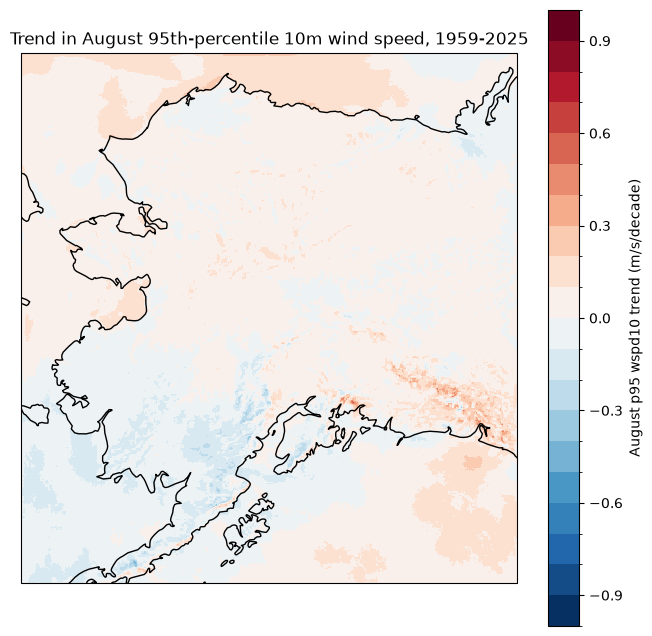

In [ ]:

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})

mesh = slope_per_decade.plot.pcolormesh(
    x="XLONG", y="XLAT", ax=ax,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-1, vmax=1,
    add_colorbar=False, levels=np.linspace(-1, 1, 21)
)
ax.coastlines()
plt.colorbar(mesh, ax=ax, label="August p95 wspd10 trend (m/s/decade)")
ax.set_title(f"Trend in August {int(PERCENTILE * 100)}th-percentile 10m wind speed, {YEARS.start}-{YEARS.stop - 1}")
plt.show()

## 1b. August hours exceeding 5 m/s -- trend

In [ ]:
exceed_fit = aug_exceed.polyfit(dim="year", deg=1)
exceed_slope_per_decade = exceed_fit.polyfit_coefficients.sel(degree=1) * 10
exceed_slope_per_decade.name = "exceed_hours_trend_per_decade"
exceed_slope_per_decade = exceed_slope_per_decade.assign_coords(
    XLAT=aug_exceed["XLAT"], XLONG=aug_exceed["XLONG"]
)
exceed_slope_per_decade

<xarray.DataArray 'exceed_hours_trend_per_decade' (south_north: 450,
                                                   west_east: 420)> Size: 2MB
array([[-9.05858408, -9.06896001, -8.81554793, ...,  2.00774204,
         1.68688642,  1.49812435],
       [-9.3455184 , -9.19147578, -8.83709793, ...,  1.87046053,
         1.625429  ,  1.38558544],
       [-9.51233139, -9.31718413, -9.00790167, ...,  1.55279751,
         1.34966877,  0.96935111],
       ...,
       [19.60890733, 20.21749541, 20.96655759, ...,  1.06991779,
         0.71514087,  1.72639476],
       [19.29363876, 19.83438423, 20.72272328, ...,  1.40274563,
         1.59350307,  2.66381994],
       [19.01029611, 19.48319898, 19.82919626, ...,  0.98730944,
         1.21837337,  2.02769575]], shape=(450, 420))
Coordinates:
    degree   int64 8B 1
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
Dimensions without coordinates: south_north, west_east

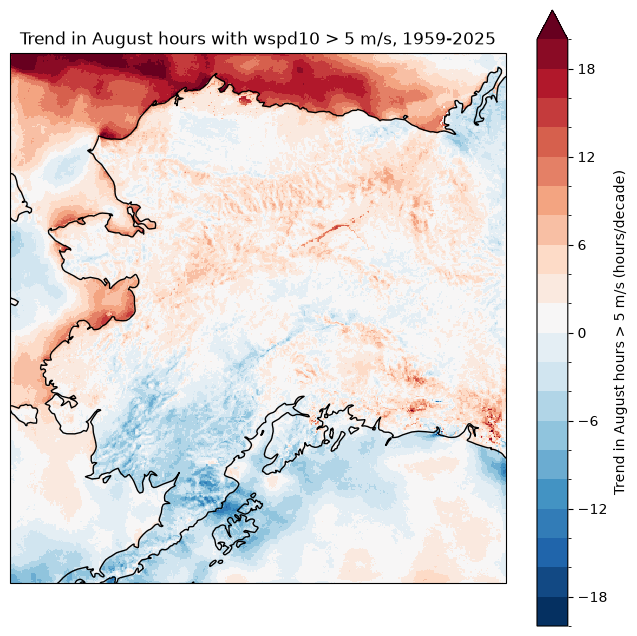

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
mesh = exceed_slope_per_decade.plot.pcolormesh(
    x="XLONG", y="XLAT", ax=ax,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-20, vmax=20,
    add_colorbar=False, levels=np.linspace(-20, 20, 21)
)
ax.coastlines()
plt.colorbar(mesh, ax=ax, label="Trend in August hours > 5 m/s (hours/decade)")
ax.set_title(f"Trend in August hours with wspd10 > {EXCEED_THRESHOLD:g} m/s, {YEARS.start}-{YEARS.stop - 1}")
plt.show()

## 1c. Theil-Sen trend and Mann-Kendall significance

Alternative to the OLS `polyfit` trend above: per-pixel Theil-Sen slope with a two-sided Mann-Kendall test for monotonic trend
(`pymannkendall.original_test`, alpha=0.05 or 0.1). Applied to both the August p95 wind speed and exceedance-hours series computed in section 1.

In [ ]:
import pymannkendall as mk

MK_ALPHA = 0.1


def _mk_all(y, alpha=MK_ALPHA):
    if np.isnan(y).any():
        return np.nan, np.nan, False
    r = mk.original_test(y, alpha=alpha)
    return r.slope, r.p, r.h

def theil_sen_mk(da, dim="year", alpha=MK_ALPHA):
    slope, pvalue, significant = xr.apply_ufunc(
        _mk_all, da.chunk({dim: -1, "south_north": 50}), kwargs={"alpha": alpha},
        input_core_dims=[[dim]], output_core_dims=[[], [], []],
        vectorize=True, dask="parallelized", output_dtypes=[float, float, bool],
    )
    return slope * 10, pvalue, significant


In [ ]:
p95_ts_slope, p95_ts_pvalue, p95_ts_significant =  dask.compute(
    *theil_sen_mk(aug_p), scheduler="processes", num_workers=N_JOBS
)

p95_ts_slope.name = "trend_m_s_per_decade_theilsen"

n_sig = int(p95_ts_significant.sum())
n_total = p95_ts_significant.size
print(f"August p95 wspd10: {n_sig}/{n_total} pixels MK-significant at alpha={MK_ALPHA}")

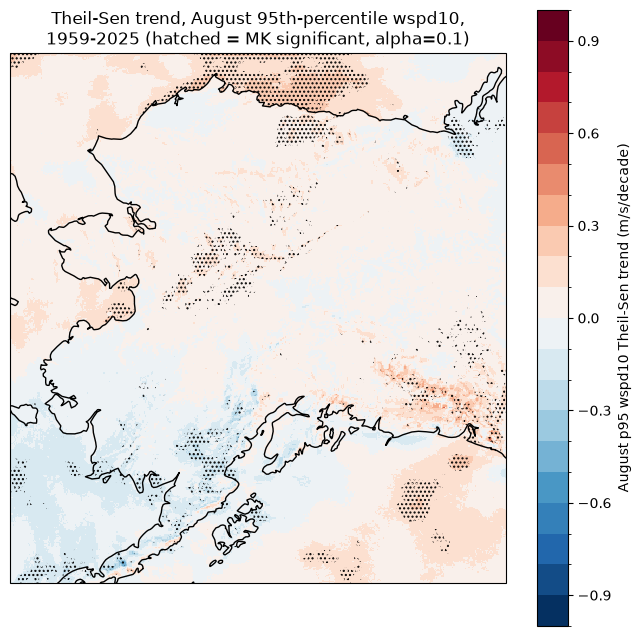

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
mesh = p95_ts_slope.plot.pcolormesh(
    x="XLONG", y="XLAT", ax=ax,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-1, vmax=1,
    add_colorbar=False, levels=np.linspace(-1, 1, 21)
)

p95_ts_significant.where(p95_ts_significant).plot.contourf(
    x="XLONG", y="XLAT", ax=ax, transform=ccrs.PlateCarree(),
    colors="none", add_colorbar=False, hatches=["....", None], levels=[0.5, 1.5],
)
ax.coastlines()
plt.colorbar(mesh, ax=ax, label="August p95 wspd10 Theil-Sen trend (m/s/decade)")
ax.set_title(
    f"Theil-Sen trend, August {int(PERCENTILE * 100)}th-percentile wspd10,\n"
    f"{YEARS.start}-{YEARS.stop - 1} (hatched = MK significant, alpha={MK_ALPHA})"
)
plt.show()

In [ ]:

exceed_ts_slope, exceed_ts_pvalue, exceed_ts_significant = dask.compute(
    *theil_sen_mk(aug_exceed), scheduler="processes", num_workers=N_JOBS
)
exceed_ts_slope.name = "exceed_hours_trend_per_decade_theilsen"

n_sig = int(exceed_ts_significant.sum())
n_total = exceed_ts_significant.size
print(f"August exceed hours: {n_sig}/{n_total} pixels MK-significant at alpha={MK_ALPHA}")

August exceed hours: 32577/189000 pixels MK-significant at alpha=0.1


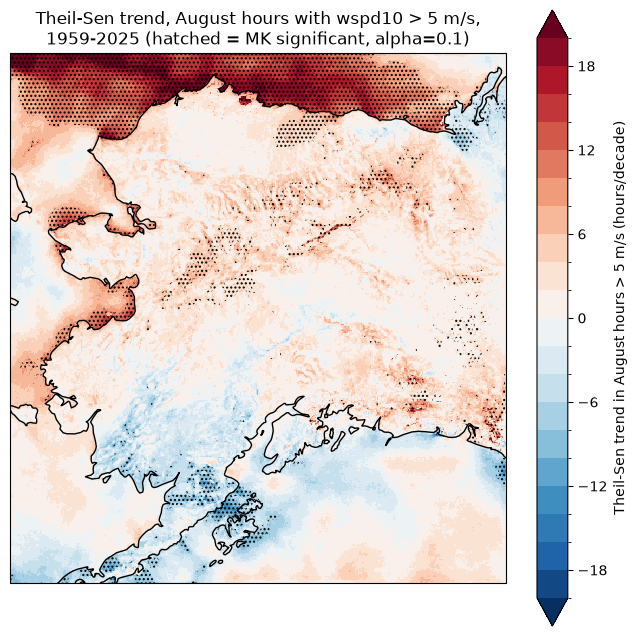

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
mesh = exceed_ts_slope.plot.pcolormesh(
    x="XLONG", y="XLAT", ax=ax,
    transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-20, vmax=20,
    add_colorbar=False, levels=np.linspace(-20, 20, 21)
)
exceed_ts_significant.where(exceed_ts_significant).plot.contourf(
    x="XLONG", y="XLAT", ax=ax, transform=ccrs.PlateCarree(),
    colors="none", add_colorbar=False, hatches=["....", None], levels=[0.5, 1.5],
)
ax.coastlines()
plt.colorbar(mesh, ax=ax, label="Theil-Sen trend in August hours > 5 m/s (hours/decade)")
ax.set_title(
    f"Theil-Sen trend, August hours with wspd10 > {EXCEED_THRESHOLD:g} m/s,\n"
    f"{YEARS.start}-{YEARS.stop - 1} (hatched = MK significant, alpha={MK_ALPHA})"
)
plt.show()

# 2. Export as GeoTIFF

Convert and save all outputs to GeoTIFF via `dyndowntools.wrf_geotiff.to_geotiff`, in the WRF grid's polar-stereographic CRS so
they're written as one band per year.

In [ ]:
GEOTIFF_DIR = Path("tasks/evaluation/working/geotiff")
GEOTIFF_DIR.mkdir(parents=True, exist_ok=True)
pct_label = f"p{int(PERCENTILE * 100)}"
exceed_label = f"exceed{EXCEED_THRESHOLD:g}mps"
yr_label = f"{YEARS.start}_{YEARS.stop - 1}"

outputs = {
    f"wspd10_{pct_label}_august_{yr_label}.tif": aug_p,
    f"wspd10_{pct_label}_august_trend_mps_per_decade_{yr_label}.tif": slope_per_decade,
    f"wspd10_{pct_label}_august_ts_trend_mps_per_decade_{yr_label}.tif": p95_ts_slope,
    f"wspd10_{exceed_label}_august_hours_{yr_label}.tif": aug_exceed,
    f"wspd10_{exceed_label}_august_hours_trend_per_decade_{yr_label}.tif": exceed_slope_per_decade,
    f"wspd10_{exceed_label}_august_hours_ts_trend_per_decade_{yr_label}.tif": exceed_ts_slope,
}
written = {}
for filename, da in outputs.items():
    written[filename] = to_geotiff(da, GEOTIFF_DIR / filename)

for filename, da in outputs.items():
    if "year" in da.dims:
        with rasterio.open(written[filename], "r+") as dst:
            for band, year in enumerate(YEARS, start=1):
                dst.set_band_description(band, str(year))

for path in written.values():
    print(path)

tasks/evaluation/working/geotiff/wspd10_p95_august_1985_2025.tif
tasks/evaluation/working/geotiff/wspd10_p95_august_trend_mps_per_decade_1985_2025.tif
tasks/evaluation/working/geotiff/wspd10_p95_august_ts_trend_mps_per_decade_1985_2025.tif
tasks/evaluation/working/geotiff/wspd10_exceed5mps_august_hours_1985_2025.tif
tasks/evaluation/working/geotiff/wspd10_exceed5mps_august_hours_trend_per_decade_1985_2025.tif
tasks/evaluation/working/geotiff/wspd10_exceed5mps_august_hours_ts_trend_per_decade_1985_2025.tif
